<a href="https://colab.research.google.com/github/youefkh05/AquaVision_Sustainable/blob/main/AquaVision_AI_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Step 1: Load the Aquaculture Water Quality Dataset

In this step, we load the **Aquaculture – Water Quality Dataset** (Mendeley Data, 2024) directly from its online source.  
This dataset contains 4,300 records and 14 water quality parameters (Temperature, DO, pH, BOD, CO₂, etc.) with a label column **Water Quality**,  
classified as:
- `0` → Excellent  
- `1` → Good  
- `2` → Poor  

We'll locate the Excel file inside the extracted folder and preview the data.



In [4]:
import pandas as pd
import glob

# 🔍 Search all subfolders for the Excel file
excel_file = glob.glob("WQD_folder/**/*.xlsx", recursive=True)[0]
print("Found Excel file at:", excel_file)

# Load the dataset
df = pd.read_excel(excel_file)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Found Excel file at: WQD_folder/Aquaculture - Water Quality Dataset/WQD.xlsx
✅ Dataset loaded successfully!
Shape: (4300, 15)


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


# ⚙️ Step 2: Train the AquaVision Neural Network Model

We’ll now build and train a **fully-connected neural network** to classify the pond water quality into three classes:
- 0 → Excellent  
- 1 → Good  
- 2 → Poor  

### Model Setup:
- **Input:** 14 normalized water-quality features  
- **Hidden Layers:** 2 Dense layers (ReLU activation, L2 regularization = 0.01)  
- **Output Layer:** 3 neurons (Softmax activation)  
- **Optimizer:** Adam  
- **Loss Function:** Categorical Crossentropy  

We’ll use:
- **60%** → Training  
- **20%** → Cross Validation  
- **20%** → Testing  

We’ll monitor **cost (loss)** over iterations for both training and validation sets.



✅ Data split complete:
Training: (2580, 14) Validation: (860, 14) Testing: (860, 14)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5338 - loss: 1.6197 - val_accuracy: 0.8570 - val_loss: 1.0147
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8587 - loss: 0.9491 - val_accuracy: 0.8837 - val_loss: 0.7815
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8911 - loss: 0.7574 - val_accuracy: 0.8895 - val_loss: 0.6558
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8997 - loss: 0.6446 - val_accuracy: 0.8977 - val_loss: 0.5730
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9039 - loss: 0.5654 - val_accuracy: 0.8930 - val_loss: 0.5240
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9042 - loss: 0.5122 - val_accuracy: 0.9174 - val_loss: 0.4654
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9128 - loss: 0.4622 - val_accuracy: 0.9116 - val_loss: 0.4407
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9254 - loss: 0.4302 - val_accuracy: 0.9221 - val_loss: 0.4

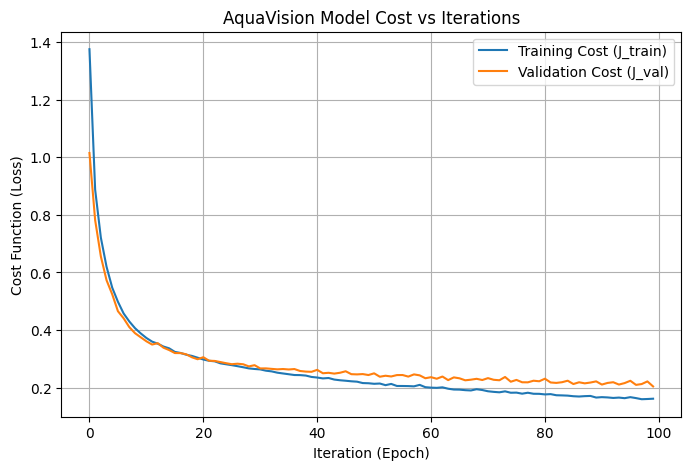


✅ Test Accuracy: 93.26%
Test Cost (Loss): 0.2399
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
❌ Misclassification Error: 6.74%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# --- Step 1: Prepare data ---
df.columns = [c.strip().replace('`','').replace('(mg L-1 )','').replace('(cm)','').replace('(mg/L)','').replace('(No. L-1)','').replace(' ','_') for c in df.columns]

X = df.drop('Water_Quality', axis=1).values
y = df['Water_Quality'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 60% Train, 20% Validation, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# (0.25 × 0.8 = 0.2 of total)

# Convert to categorical
y_train_cat = to_categorical(y_train, 3)
y_val_cat = to_categorical(y_val, 3)
y_test_cat = to_categorical(y_test, 3)

print("✅ Data split complete:")
print("Training:", X_train.shape, "Validation:", X_val.shape, "Testing:", X_test.shape)

# --- Step 2: Define neural network ---
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1], kernel_regularizer=l2(0.01)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- Step 3: Train model and record cost ---
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- Step 4: Plot cost function (J) over iterations ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Cost (J_train)')
plt.plot(val_loss, label='Validation Cost (J_val)')
plt.xlabel('Iteration (Epoch)')
plt.ylabel('Cost Function (Loss)')
plt.title('AquaVision Model Cost vs Iterations')
plt.legend()
plt.grid(True)
plt.show()

# --- Step 5: Evaluate model on test set ---
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Cost (Loss): {test_loss:.4f}")

# --- Step 6: Error percentage ---
y_pred = np.argmax(model.predict(X_test), axis=1)
error_pct = (np.sum(y_pred != y_test) / len(y_test)) * 100
print(f"❌ Misclassification Error: {error_pct:.2f}%")


# 🧩 Step 3: Save and Deploy the AquaVision Model

Now that our neural network is trained and validated, we’ll export it in two formats:

| Format | Use Case |
|:--|:--|
| **`.h5`** | Reload and continue training or testing in Python / Google Colab |
| **`.tflite`** | Deploy on embedded systems (ESP32, Raspberry Pi, etc.) using TensorFlow Lite |

After saving, we’ll confirm that both files exist and print their sizes.





In [6]:
import tensorflow as tf
import os

# --- Step 3: Save the trained model ---
# 1️⃣ Save as standard Keras model (.h5)
model.save("AquaVision_Model.h5")
print("✅ Saved AquaVision_Model.h5")

# 2️⃣ Convert to TensorFlow Lite for embedded deployment
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save TFLite model
with open("AquaVision_Model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Saved AquaVision_Model.tflite")

# 3️⃣ Verify that both files were created
for file in ["AquaVision_Model.h5", "AquaVision_Model.tflite"]:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"📦 {file}  -->  {size_kb:.2f} KB")
    else:
        print(f"⚠️ {file} not found!")

print("\n💡 Both versions are now ready for deployment or reuse.")


✅ Saved AquaVision_Model.h5
Saved artifact at '/tmp/tmp1l19jnfg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137242479211536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137242479212688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137242479211344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137242479210000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137242479213264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137242479210192: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Saved AquaVision_Model.tflite
📦 AquaVision_Model.h5  -->  68.73 KB
📦 AquaVision_Model.tflite  -->  14.32 KB

💡 Both versions are now ready for deployment or reuse.


# 🔍 Step 4: Real-Time Prediction Test

Now that the AquaVision model is trained and exported, let’s simulate a real-time reading from the water-quality sensors.

We’ll:
1. Reload the saved model (`AquaVision_Model.h5`)
2. Create a **sample sensor input** (Temperature, pH, DO, etc.)
3. Standardize it using the same scaler
4. Predict the **water quality class**
5. Print the corresponding label:
   - `0 → Excellent`
   - `1 → Good`
   - `2 → Poor`



In [7]:
import numpy as np
from tensorflow.keras.models import load_model

# --- Step 1: Load the trained model ---
model = load_model("AquaVision_Model.h5")
print("✅ AquaVision model loaded successfully!")

# --- Step 2: Define label names ---
labels = {0: "Excellent 🌊", 1: "Good ✅", 2: "Poor ⚠️"}

# --- Step 3: Example real-time sensor input ---
# Replace with real AquaVision readings:
sample_data = {
    "Temp": 28.0,
    "Turbidity": 4.5,
    "DO": 6.8,
    "BOD": 7.0,
    "CO2": 10.5,
    "pH": 7.4,
    "Alkalinity": 250,
    "Hardness": 300,
    "Calcium": 320,
    "Ammonia": 0.2,
    "Nitrite": 4.0,
    "Phosphorus": 0.005,
    "H2S": 0.06,
    "Plankton": 5000
}

# --- Step 4: Convert to model input ---
input_vector = np.array([list(sample_data.values())])

# Apply the same scaler used during training
input_scaled = scaler.transform(input_vector)

# --- Step 5: Predict water quality ---
pred = np.argmax(model.predict(input_scaled), axis=1)[0]
pred_label = labels[pred]

print("\n🌡️ Sensor Input:")
for k, v in sample_data.items():
    print(f"{k:15s}: {v}")

print(f"\n🤖 Predicted Water Quality: {pred_label}")


✅ AquaVision model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step

🌡️ Sensor Input:
Temp           : 28.0
Turbidity      : 4.5
DO             : 6.8
BOD            : 7.0
CO2            : 10.5
pH             : 7.4
Alkalinity     : 250
Hardness       : 300
Calcium        : 320
Ammonia        : 0.2
Nitrite        : 4.0
Phosphorus     : 0.005
H2S            : 0.06
Plankton       : 5000

🤖 Predicted Water Quality: Poor ⚠️
